# EDA: Datos de Calidad del Aire — Estación Acopi/Yumbo
## y fusión con dataset DAGMA para enriquecer ground truth de NO₂

**Contexto:** El dataset original del DAGMA (9 estaciones en Cali) solo tiene NO₂ en la estación Univalle (~69% cobertura).
Para mejorar la validación del modelo en la Situación 3, descargamos datos de la estación **Acopi (Yumbo)** desde
Datos Abiertos Colombia — CVC, que cubre el corredor industrial Yumbo-Acopi.

**Objetivos:**
1. Explorar el dataset descargado de la CVC (Acopi + Yumbo)
2. Extraer las series de NO₂ del período 2020-2023
3. Fusionar los datos de NO₂ de Acopi con el dataset DAGMA original
4. Generar un dataset enriquecido con ground truth de NO₂ en **dos estaciones**: Univalle y Acopi

In [1]:
# @title Instalar dependencias
%pip install -q pandas numpy matplotlib seaborn tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5), 'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10})
print('Librerías OK')

Note: you may need to restart the kernel to use updated packages.
Librerías OK


---
## 1. Cargar dataset de la CVC (Acopi + Yumbo)
El dataset tiene formato **largo** (tidy data): cada fila es una medición de un contaminante en un intervalo horario.

In [2]:
DATA_DIR = Path(r"C:\Users\nicor\universidad\analitica\proyectos\proyecto 3.1\notebooks\Situacion_1\Datos")
acopi_path = DATA_DIR / "Calidad_del_Aire_en_Acopi_20260525.csv"
print(f"Cargando: {acopi_path}")
print(f"Tamaño: {acopi_path.stat().st_size / 1e6:.1f} MB")
chunks = []
for chunk in pd.read_csv(acopi_path, encoding='utf-8', chunksize=50000, low_memory=False):
    chunks.append(chunk)
df_acopi = pd.concat(chunks, ignore_index=True)
print(f"Shape: {df_acopi.shape}")
print(f"Columnas: {list(df_acopi.columns)}")

Cargando: C:\Users\nicor\universidad\analitica\proyectos\proyecto 3.1\notebooks\Situacion_1\Datos\Calidad_del_Aire_en_Acopi_20260525.csv
Tamaño: 116.6 MB
Shape: (567039, 18)
Columnas: ['ESTACION_ID', 'NOMBRE_FGDA', 'NOMBRE_EST', 'MSFL_CODE', 'MED_CONCENTRACION_ESTANDAR', 'MED_FECHA_INICIO', 'MED_FECHA_FINAL', 'LATITUD', 'LONGITUD', 'ALTITUD', 'NOMBRE_UNIDAD', 'SIGLA_UNIDAD', 'DURACIÓN', 'CODIGO_DEPARTAMENTO', 'DEPARTAMENTO', 'CODIGO_MUNICIPIO', 'MUNICIPIO', 'TIPO_ESTACION']


In [3]:
df_acopi.head(10)

,ESTACION_ID,NOMBRE_FGDA,NOMBRE_EST,MSFL_CODE,MED_CONCENTRACION_ESTANDAR,MED_FECHA_INICIO,MED_FECHA_FINAL,LATITUD,LONGITUD,ALTITUD,NOMBRE_UNIDAD,SIGLA_UNIDAD,DURACIÓN,CODIGO_DEPARTAMENTO,DEPARTAMENTO,CODIGO_MUNICIPIO,MUNICIPIO,TIPO_ESTACION
0,8776,CVC,ACOPI,PM2.5,19.97,2020 Jan 01 12:00:00 AM,2020 Jan 01 01:00:00 AM,3.49625,-76.506972,950,Microgramos por metro cúbico,ug/m3,60,76,Valle del Cauca,76892,Yumbo,Fija
1,8776,CVC,ACOPI,PM10,36.04,2020 Jan 01 12:00:00 AM,2020 Jan 01 01:00:00 AM,3.49625,-76.506972,950,Microgramos por metro cúbico,ug/m3,60,76,Valle del Cauca,76892,Yumbo,Fija
2,8776,CVC,ACOPI,PM10,49.59,2020 Jan 01 01:00:00 AM,2020 Jan 01 02:00:00 AM,3.49625,-76.506972,950,Microgramos por metro cúbico,ug/m3,60,76,Valle del Cauca,76892,Yumbo,Fija
3,8776,CVC,ACOPI,PM2.5,40.5,2020 Jan 01 01:00:00 AM,2020 Jan 01 02:00:00 AM,3.49625,-76.506972,950,Microgramos por metro cúbico,ug/m3,60,76,Valle del Cauca,76892,Yumbo,Fija
4,8776,CVC,ACOPI,PM10,74.81,2020 Jan 01 02:00:00 AM,2020 Jan 01 03:00:00 AM,3.49625,-76.506972,950,Microgramos por metro cúbico,ug/m3,60,76,Valle del Cauca,76892,Yumbo,Fija
5,8776,CVC,ACOPI,PM2.5,57.83,2020 Jan 01 02:00:00 AM,2020 Jan 01 03:00:00 AM,3.49625,-76.506972,950,Microgramos por metro cúbico,ug/m3,60,76,Valle del Cauca,76892,Yumbo,Fija
6,8776,CVC,ACOPI,PM10,62.08,2020 Jan 01 03:00:00 AM,2020 Jan 01 04:00:00 AM,3.49625,-76.506972,950,Microgramos por metro cúbico,ug/m3,60,76,Valle del Cauca,76892,Yumbo,Fija
7,8776,CVC,ACOPI,PM2.5,45.76,2020 Jan 01 03:00:00 AM,2020 Jan 01 04:00:00 AM,3.49625,-76.506972,950,Microgramos por metro cúbico,ug/m3,60,76,Valle del Cauca,76892,Yumbo,Fija
8,8776,CVC,ACOPI,PM10,31.03,2020 Jan 01 05:00:00 AM,2020 Jan 01 06:00:00 AM,3.49625,-76.506972,950,Microgramos por metro cúbico,ug/m3,60,76,Valle del Cauca,76892,Yumbo,Fija
9,8776,CVC,ACOPI,PM2.5,19.29,2020 Jan 01 05:00:00 AM,2020 Jan 01 06:00:00 AM,3.49625,-76.506972,950,Microgramos por metro cúbico,ug/m3,60,76,Valle del Cauca,76892,Yumbo,Fija


In [4]:
df_acopi.rename(columns={'MED_CONCENTRACION_ESTANDAR': 'concentracion', 'MED_FECHA_INICIO': 'fecha_inicio', 'MED_FECHA_FINAL': 'fecha_fin'}, inplace=True)
df_acopi['fecha_inicio'] = pd.to_datetime(df_acopi['fecha_inicio'], errors='coerce')
df_acopi['fecha_fin'] = pd.to_datetime(df_acopi['fecha_fin'], errors='coerce')
df_acopi['concentracion'] = pd.to_numeric(df_acopi['concentracion'], errors='coerce')
print('Conversión OK')
print(f'Rango fechas: {df_acopi["fecha_inicio"].min()} a {df_acopi["fecha_inicio"].max()}')

Conversión OK
Rango fechas: 2020-01-01 00:00:00 a 2024-12-31 23:00:00


---
## 2. Análisis exploratorio del dataset CVC

In [5]:
print("=== VARIABLES (MSFL_CODE) ===")
var_counts = df_acopi['MSFL_CODE'].value_counts()
for code, count in var_counts.items():
    print(f"  {code:12s}: {count:6d} registros")
print(f"\n=== ESTACIONES ===")
print(df_acopi['NOMBRE_EST'].value_counts())

=== VARIABLES (MSFL_CODE) ===
  VViento     :  78811 registros
  DViento     :  76878 registros
  P           :  67760 registros
  PM2.5       :  67646 registros
  PM10        :  56951 registros
  TAire10     :  56205 registros
  HAire10     :  56071 registros
  TAire2      :  22429 registros
  HAire2      :  22390 registros
  O3          :  16091 registros
  RGlobal     :  16006 registros
  SO2         :  12035 registros
  PLiquida    :   6994 registros
  NO2         :   6246 registros
  CO          :   4526 registros

=== ESTACIONES ===
NOMBRE_EST
ESTACIÓN YUMBO    260162
ACOPI             172094
LAS AMÉRICAS      134783
Name: count, dtype: int64


In [6]:
df_no2 = df_acopi[df_acopi['MSFL_CODE'] == 'NO2'].copy()
print(f"Registros NO2: {len(df_no2)}")
print(f"Período: {df_no2['fecha_inicio'].min()} a {df_no2['fecha_inicio'].max()}")
print(f"\nEstadísticos NO2 (µg/m³):")
print(df_no2['concentracion'].describe())
df_no2['year'] = df_no2['fecha_inicio'].dt.year
print(f"\nRegistros por año:")
print(df_no2.groupby('year').size())

Registros NO2: 6246
Período: 2020-11-01 00:00:00 a 2024-04-17 23:00:00

Estadísticos NO2 (µg/m³):
count    6246.000000
mean       10.072486
std         9.502249
min         0.000000
25%         4.200000
50%         8.700000
75%        13.050000
max       163.900000
Name: concentracion, dtype: float64

Registros por año:
year
2020    1261
2021    3303
2023    1498
2024     184
dtype: int64


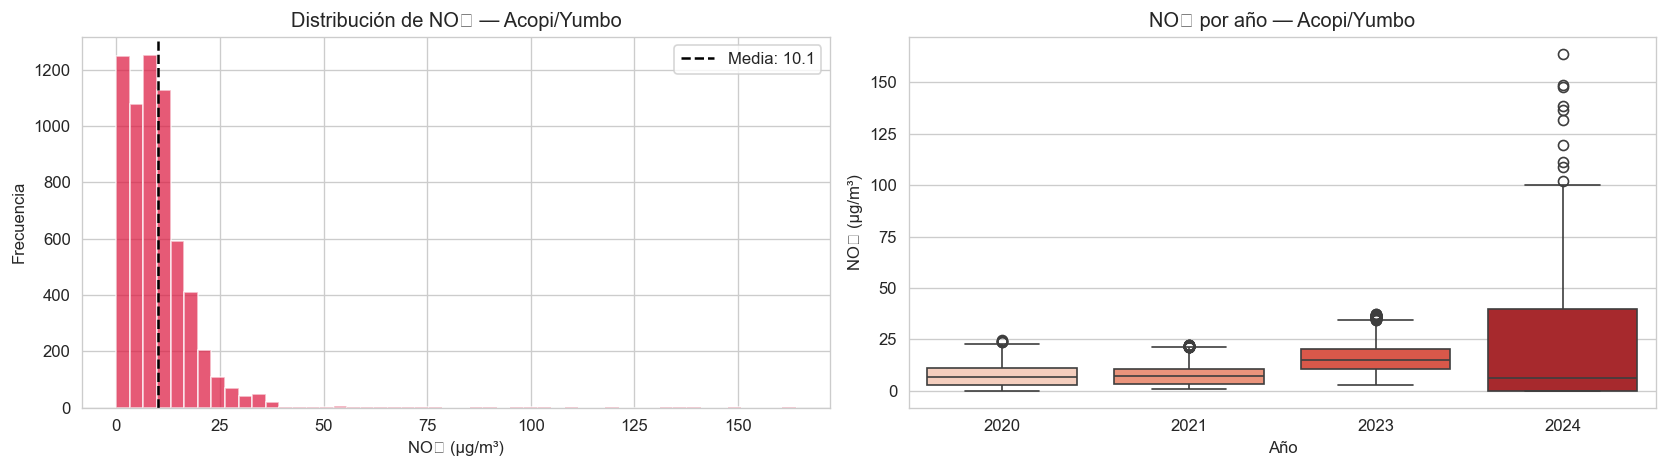

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_no2['concentracion'].dropna(), bins=50, color='crimson', edgecolor='white', alpha=0.7)
axes[0].axvline(df_no2['concentracion'].mean(), color='black', ls='--', label=f"Media: {df_no2['concentracion'].mean():.1f}")
axes[0].set_xlabel('NO₂ (µg/m³)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de NO₂ — Acopi/Yumbo')
axes[0].legend()
df_no2_box = df_no2.dropna(subset=['concentracion']).copy()
sns.boxplot(x='year', y='concentracion', data=df_no2_box, ax=axes[1], palette='Reds')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('NO₂ (µg/m³)')
axes[1].set_title('NO₂ por año — Acopi/Yumbo')
plt.tight_layout()
plt.show()

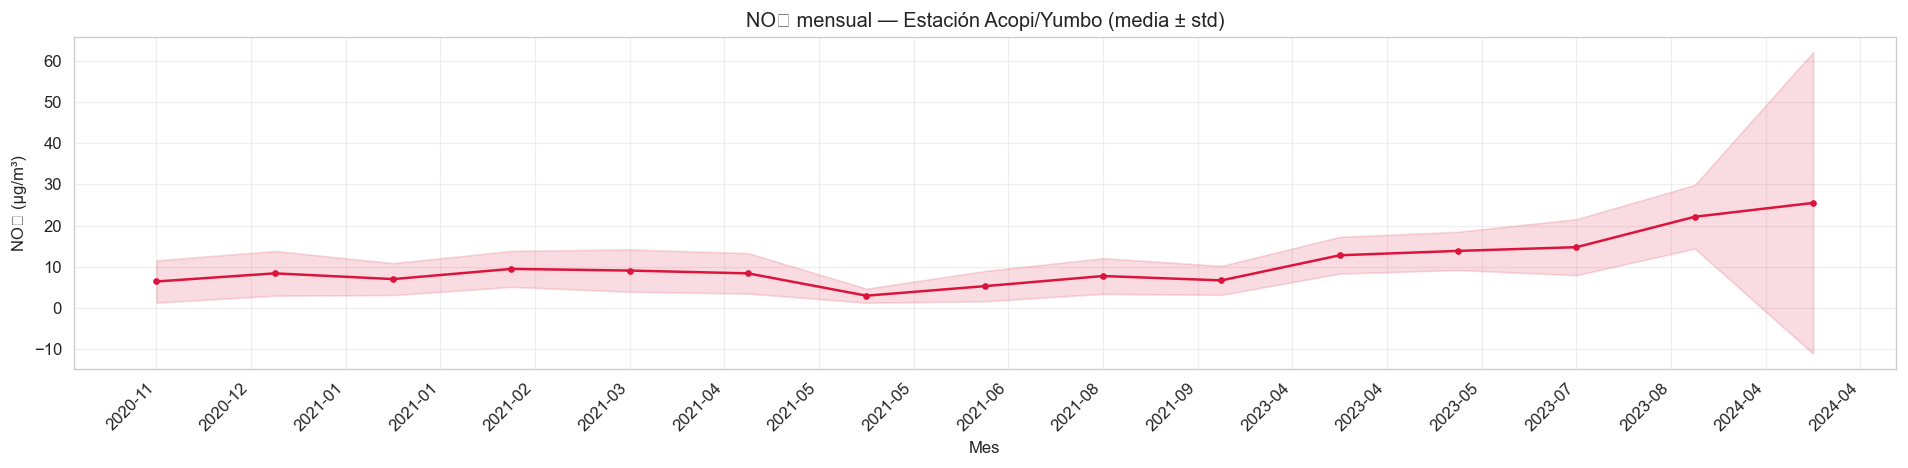

Media general NO₂ Acopi: 10.7 µg/m³


In [8]:
df_no2['month'] = df_no2['fecha_inicio'].dt.to_period('M')
monthly_no2 = df_no2.groupby('month')['concentracion'].agg(['mean', 'std', 'count'])
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(monthly_no2.index.astype(str), monthly_no2['mean'], color='crimson', linewidth=1.5, marker='o', markersize=3)
ax.fill_between(range(len(monthly_no2)), monthly_no2['mean'] - monthly_no2['std'], monthly_no2['mean'] + monthly_no2['std'], alpha=0.15, color='crimson')
ax.set_xlabel('Mes')
ax.set_ylabel('NO₂ (µg/m³)')
ax.set_title('NO₂ mensual — Estación Acopi/Yumbo (media ± std)')
ax.xaxis.set_major_locator(mticker.MaxNLocator(20))
plt.xticks(rotation=45, ha='right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Media general NO₂ Acopi: {monthly_no2['mean'].mean():.1f} µg/m³")

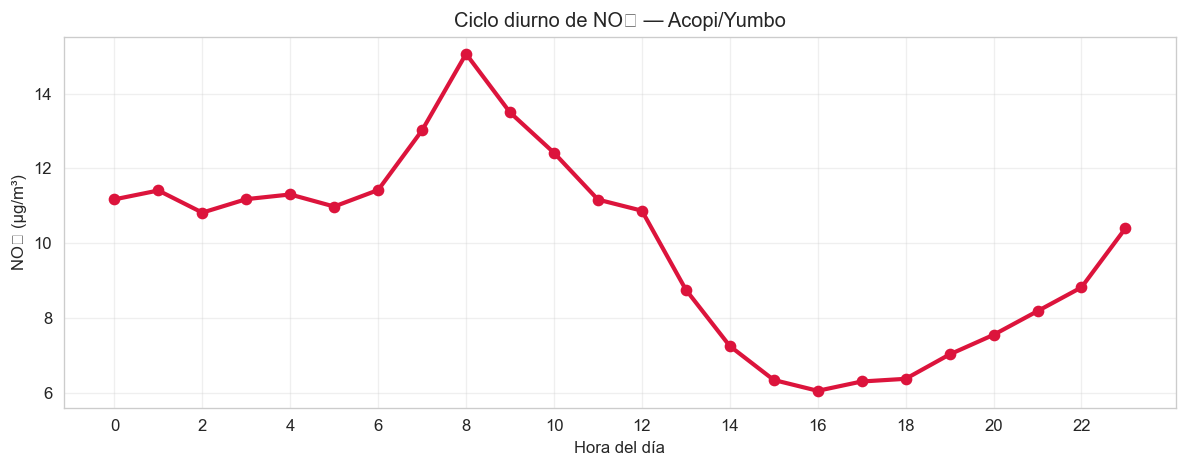

Pico máximo de NO₂ a las 8:00 con 15.1 µg/m³


In [9]:
df_no2['hour'] = df_no2['fecha_inicio'].dt.hour
hourly_no2 = df_no2.groupby('hour')['concentracion'].mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_no2.index, hourly_no2.values, color='crimson', linewidth=2.5, marker='o', markersize=6)
ax.set_xlabel('Hora del día')
ax.set_ylabel('NO₂ (µg/m³)')
ax.set_title('Ciclo diurno de NO₂ — Acopi/Yumbo')
ax.set_xticks(range(0, 24, 2))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
if len(hourly_no2) > 0:
    max_hour = hourly_no2.idxmax()
    print(f"Pico máximo de NO₂ a las {max_hour}:00 con {hourly_no2[max_hour]:.1f} µg/m³")

Filas con datos simultáneos: 5792

Correlación NO₂ entre estaciones:
              Univalle_NO2  Acopi_NO2
Univalle_NO2         1.000     -0.187
Acopi_NO2           -0.187      1.000


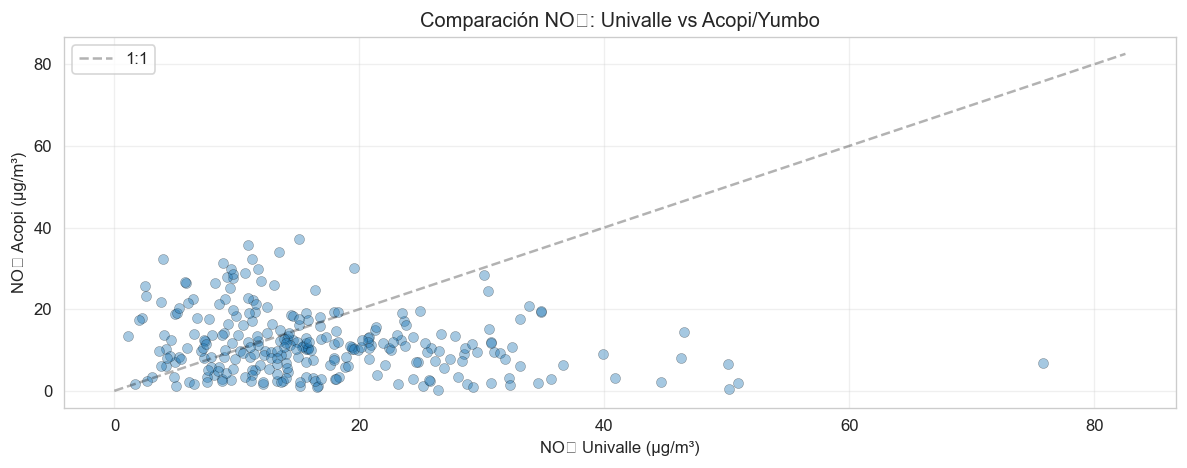

In [10]:
dagma_path = DATA_DIR / "DAGMAdatos.csv"
df_dagma = pd.read_csv(dagma_path, parse_dates=['Fecha_Hora'], usecols=['Fecha_Hora', 'Univalle_NO2', 'Flora_NO2'])
df_dagma['date_hour'] = df_dagma['Fecha_Hora'].dt.floor('h')
df_no2_hourly = df_no2.groupby('fecha_inicio')['concentracion'].mean().reset_index()
df_no2_hourly.rename(columns={'fecha_inicio': 'date_hour', 'concentracion': 'Acopi_NO2'}, inplace=True)
df_compare = df_dagma.merge(df_no2_hourly, on='date_hour', how='inner')
print(f"Filas con datos simultáneos: {len(df_compare)}")
print(f"\nCorrelación NO₂ entre estaciones:")
print(df_compare[['Univalle_NO2', 'Acopi_NO2']].corr().round(3))
fig, ax = plt.subplots(figsize=(10, 4))
sample = df_compare.sample(min(500, len(df_compare)))
ax.scatter(sample['Univalle_NO2'], sample['Acopi_NO2'], alpha=0.4, edgecolor='k', linewidth=0.3)
ax.set_xlabel('NO₂ Univalle (µg/m³)')
ax.set_ylabel('NO₂ Acopi (µg/m³)')
ax.set_title('Comparación NO₂: Univalle vs Acopi/Yumbo')
ax.grid(True, alpha=0.3)
lims = [0, max(df_compare['Univalle_NO2'].max(), df_compare['Acopi_NO2'].max())]
ax.plot(lims, lims, 'k--', alpha=0.3, label='1:1')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Verificar overlap temporal entre CVC y DAGMA

Antes de pivotear y fusionar, verificamos cuantas horas de NO2
de la estacion Yumbo (CVC) realmente caen dentro del periodo del DAGMA (2020-2023).

In [11]:
print("=" * 60)
print("VERIFICACION DE OVERLAP TEMPORAL")
print("=" * 60)

# Cargar DAGMA solo para ver fechas
dagma_path = DATA_DIR / "DAGMAdatos.csv"
df_dagma_fechas = pd.read_csv(dagma_path, parse_dates=["Fecha_Hora"], usecols=["Fecha_Hora"])
print(f'DAGMA: {df_dagma_fechas["Fecha_Hora"].min()} a {df_dagma_fechas["Fecha_Hora"].max()}')
print(f'DAGMA: {len(df_dagma_fechas):,} filas')

# Fechas de NO2 en CVC
fechas_cvc = df_no2[["fecha_inicio"]].copy()
fechas_cvc["hora"] = fechas_cvc["fecha_inicio"].dt.floor("h")
print(f'NO2 CVC: {fechas_cvc["hora"].min()} a {fechas_cvc["hora"].max()}')
print(f'NO2 CVC: {len(fechas_cvc):,} registros')

# Overlap
inicio_overlap = max(df_dagma_fechas['Fecha_Hora'].min(), fechas_cvc['hora'].min())
fin_overlap = min(df_dagma_fechas['Fecha_Hora'].max(), fechas_cvc['hora'].max())
print(f'Overlap temporal: {inicio_overlap} a {fin_overlap}')

# NO2 CVC dentro del periodo DAGMA
cvc_en_dagma = fechas_cvc[(fechas_cvc['hora'] >= df_dagma_fechas['Fecha_Hora'].min()) & (fechas_cvc['hora'] <= df_dagma_fechas['Fecha_Hora'].max())]
print(f'Registros NO2 CVC dentro del periodo DAGMA: {len(cvc_en_dagma):,}')

if inicio_overlap < fin_overlap:
    print('>> HAY OVERLAP. Procedemos con el merge.')
else:
    print('>> NO HAY OVERLAP. Revisar fechas.')
print("=" * 60)

VERIFICACION DE OVERLAP TEMPORAL
DAGMA: 2020-01-01 01:00:00 a 2023-12-30 23:00:00
DAGMA: 33,580 filas
NO2 CVC: 2020-11-01 00:00:00 a 2024-04-17 23:00:00
NO2 CVC: 6,246 registros
Overlap temporal: 2020-11-01 00:00:00 a 2023-12-30 23:00:00
Registros NO2 CVC dentro del periodo DAGMA: 6,062
>> HAY OVERLAP. Procedemos con el merge.


---
## 4. Pivot: de formato largo a ancho

In [12]:
print("Pivotando datos a formato ancho...")
# Usamos fecha_inicio (NO fecha_fin) para alinear con DAGMA
df_pivot = df_acopi[["fecha_inicio", "MSFL_CODE", "concentracion", "NOMBRE_EST"]].copy()
df_pivot["hora"] = df_pivot["fecha_inicio"].dt.floor("h")
# Promediar si hay duplicados en misma hora y codigo
df_pivot = df_pivot.groupby(["hora", "MSFL_CODE"], as_index=False)["concentracion"].mean()
# Pivot a formato ancho
df_wide = df_pivot.pivot(index="hora", columns="MSFL_CODE", values="concentracion")
df_wide.columns = ["CVC_" + col for col in df_wide.columns]
df_wide.reset_index(inplace=True)
df_wide.rename(columns={"hora": "Fecha_Hora"}, inplace=True)
print(f'Shape wide: {df_wide.shape}')
print(f'Columnas: {list(df_wide.columns)}')
print(f'NO disponible desde: {df_wide["Fecha_Hora"].min()} hasta {df_wide["Fecha_Hora"].max()}')
df_wide.head()

Pivotando datos a formato ancho...
Shape wide: (42080, 16)
Columnas: ['Fecha_Hora', 'CVC_CO', 'CVC_DViento', 'CVC_HAire10', 'CVC_HAire2', 'CVC_NO2', 'CVC_O3', 'CVC_P', 'CVC_PLiquida', 'CVC_PM10', 'CVC_PM2.5', 'CVC_RGlobal', 'CVC_SO2', 'CVC_TAire10', 'CVC_TAire2', 'CVC_VViento']
NO disponible desde: 2020-01-01 00:00:00 hasta 2024-12-31 23:00:00


,Fecha_Hora,CVC_CO,CVC_DViento,CVC_HAire10,CVC_HAire2,CVC_NO2,CVC_O3,CVC_P,CVC_PLiquida,CVC_PM10,CVC_PM2.5,CVC_RGlobal,CVC_SO2,CVC_TAire10,CVC_TAire2,CVC_VViento
0,2020-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.04,19.97,NaN,NaN,NaN,NaN,NaN
1,2020-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.59,40.50,NaN,NaN,NaN,NaN,NaN
2,2020-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.81,57.83,NaN,NaN,NaN,NaN,NaN
3,2020-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.08,45.76,NaN,NaN,NaN,NaN,NaN
4,2020-01-01 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.03,19.29,NaN,NaN,NaN,NaN,NaN


In [13]:
print(f"Rango: {df_wide['Fecha_Hora'].min()} a {df_wide['Fecha_Hora'].max()}")
print(f"Total filas: {len(df_wide)}")
print(f"\nCobertura NO2 en el pivot:")
print(f"  Registros: {df_wide['CVC_NO2'].notna().sum()}")
print(f"  Cobertura: {df_wide['CVC_NO2'].notna().mean()*100:.1f}%")

Rango: 2020-01-01 00:00:00 a 2024-12-31 23:00:00
Total filas: 42080

Cobertura NO2 en el pivot:
  Registros: 6246
  Cobertura: 14.8%


---
## 5. Cargar dataset DAGMA original y fusionar

In [14]:
print("Cargando DAGMA original...")
df_dagma_full = pd.read_csv(dagma_path, parse_dates=['Fecha_Hora'], low_memory=False)
print(f"Shape: {df_dagma_full.shape}")
print(f"Rango: {df_dagma_full['Fecha_Hora'].min()} a {df_dagma_full['Fecha_Hora'].max()}")

Cargando DAGMA original...
Shape: (33580, 87)
Rango: 2020-01-01 01:00:00 a 2023-12-30 23:00:00


In [15]:
print("Fusionando datasets...")
df_merged = df_dagma_full.merge(df_wide, on='Fecha_Hora', how='left')
print(f"Shape final: {df_merged.shape}")
print(f"\nNuevas columnas agregadas:")
new_cols = [c for c in df_merged.columns if c.startswith('CVC_')]
for col in new_cols:
    print(f"  {col}: {df_merged[col].notna().sum()} valores")

Fusionando datasets...
Shape final: (33580, 102)

Nuevas columnas agregadas:
  CVC_CO: 2730 valores
  CVC_DViento: 26535 valores
  CVC_HAire10: 26274 valores
  CVC_HAire2: 0 valores
  CVC_NO2: 5792 valores
  CVC_O3: 8827 valores
  CVC_P: 23154 valores
  CVC_PLiquida: 0 valores
  CVC_PM10: 27630 valores
  CVC_PM2.5: 28714 valores
  CVC_RGlobal: 9735 valores
  CVC_SO2: 6627 valores
  CVC_TAire10: 26557 valores
  CVC_TAire2: 0 valores
  CVC_VViento: 27233 valores


In [16]:
no2_cols = ['Fecha_Hora'] + [c for c in df_merged.columns if 'NO2' in c]
df_merged[no2_cols].head(10)

,Fecha_Hora,Flora_NO2,Univalle_NO2,CVC_NO2
0,2020-01-01 01:00:00,NaN,11.470491,NaN
1,2020-01-01 02:00:00,NaN,10.191813,NaN
2,2020-01-01 03:00:00,NaN,9.082372,NaN
3,2020-01-01 04:00:00,NaN,15.795430,NaN
4,2020-01-01 05:00:00,NaN,15.456956,NaN
5,2020-01-01 06:00:00,NaN,10.586699,NaN
6,2020-01-01 07:00:00,NaN,6.299368,NaN
7,2020-01-01 08:00:00,NaN,14.253495,NaN
8,2020-01-01 09:00:00,NaN,18.503218,NaN
9,2020-01-01 10:00:00,NaN,9.684103,NaN


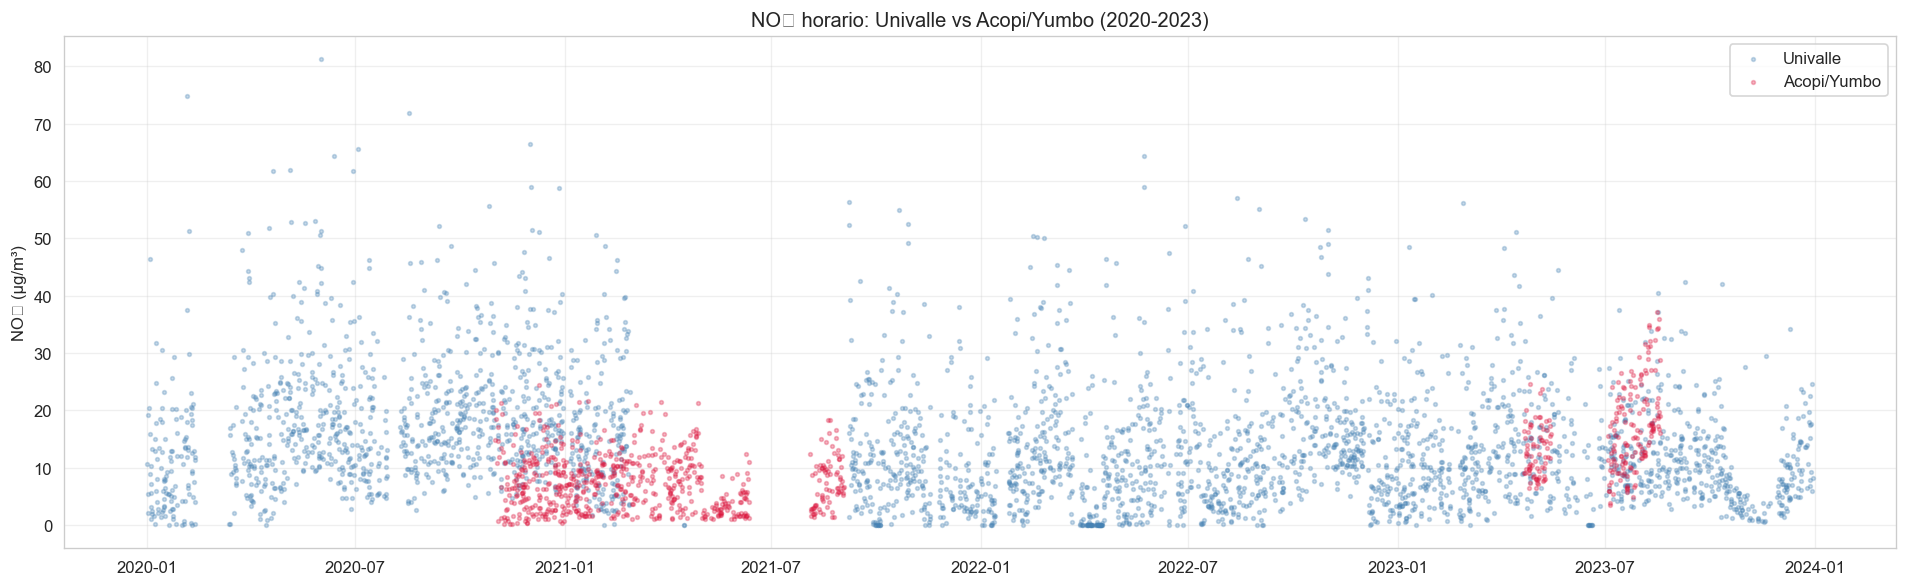

In [17]:
fig, ax = plt.subplots(figsize=(16, 5))
sample = df_merged.sample(min(5000, len(df_merged))).sort_values('Fecha_Hora')
ax.scatter(sample['Fecha_Hora'], sample['Univalle_NO2'], alpha=0.3, s=5, color='steelblue', label='Univalle')
ax.scatter(sample['Fecha_Hora'], sample['CVC_NO2'], alpha=0.3, s=5, color='crimson', label='Acopi/Yumbo')
ax.set_ylabel('NO₂ (µg/m³)')
ax.set_title('NO₂ horario: Univalle vs Acopi/Yumbo (2020-2023)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Exportar dataset enriquecido

In [18]:
output_dir = Path(r"C:\Users\nicor\universidad\analitica\proyectos\proyecto 3.1\notebooks\Situacion_1\Datos")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "DAGMA_enriquecido_Acopi_Yumbo_NO2.parquet"
print(f"Guardando en: {output_path}")
df_merged.to_parquet(output_path, index=False)
output_csv = output_dir / "DAGMA_enriquecido_Acopi_Yumbo_NO2.csv"
df_merged.to_csv(output_csv, index=False)
print(f"Guardado CSV: {output_csv}")
file_size = output_path.stat().st_size / 1e6
print(f"Tamaño Parquet: {file_size:.1f} MB")
print(f"Filas: {len(df_merged):,}")
print(f"Columnas: {len(df_merged.columns)}")

Guardando en: C:\Users\nicor\universidad\analitica\proyectos\proyecto 3.1\notebooks\Situacion_1\Datos\DAGMA_enriquecido_Acopi_Yumbo_NO2.parquet
Guardado CSV: C:\Users\nicor\universidad\analitica\proyectos\proyecto 3.1\notebooks\Situacion_1\Datos\DAGMA_enriquecido_Acopi_Yumbo_NO2.csv
Tamaño Parquet: 2.5 MB
Filas: 33,580
Columnas: 102


In [19]:
print("="*60)
print("RESUMEN — GROUND TRUTH DE NO₂ DISPONIBLE")
print("="*60)
print(f"\nEstación Univalle:")
print(f"  Registros: {df_merged['Univalle_NO2'].notna().sum():,}")
print(f"  Cobertura: {df_merged['Univalle_NO2'].notna().mean()*100:.1f}%")
print(f"  Media: {df_merged['Univalle_NO2'].mean():.1f} µg/m³")
print(f"\nEstación Acopi/Yumbo (CVC — NUEVA):")
print(f"  Registros: {df_merged['CVC_NO2'].notna().sum():,}")
print(f"  Cobertura: {df_merged['CVC_NO2'].notna().mean()*100:.1f}%")
print(f"  Media: {df_merged['CVC_NO2'].mean():.1f} µg/m³")
both = df_merged[['Univalle_NO2', 'CVC_NO2']].dropna()
print(f"\nFilas con AMBAS estaciones simultáneamente:")
print(f"  {len(both):,} ({len(both)/len(df_merged)*100:.1f}% del total)")
if len(both) > 0:
    corr = both['Univalle_NO2'].corr(both['CVC_NO2'])
    print(f"  Correlación: {corr:.3f}")
print("="*60)

RESUMEN — GROUND TRUTH DE NO₂ DISPONIBLE

Estación Univalle:
  Registros: 23,257
  Cobertura: 69.3%
  Media: 14.3 µg/m³

Estación Acopi/Yumbo (CVC — NUEVA):
  Registros: 5,792
  Cobertura: 17.2%
  Media: 9.6 µg/m³

Filas con AMBAS estaciones simultáneamente:
  3,118 (9.3% del total)
  Correlación: -0.187
